# K-Means sur le Dataset Digits

**Algorithme :** K-Means (sklearn)  
**Dataset :** Digits (sklearn) — reconnaissance de chiffres manuscrits 8×8  
**Split :** 70 % train / 15 % validation / 15 % test  
**Objectif :** Regrouper les chiffres en 10 clusters sans utiliser les labels, puis évaluer la cohérence avec la vérité terrain

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score,
    silhouette_score, confusion_matrix
)
from scipy.optimize import linear_sum_assignment

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

  DIGITS — APERÇU GÉNÉRAL
  Samples      : 1797
  Features     : 64 (pixels 8×8)
  Classes      : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Valeurs NaN  : 0

  DISTRIBUTION DES CLASSES
  Chiffre 0 : 178 samples
  Chiffre 1 : 182 samples
  Chiffre 2 : 177 samples
  Chiffre 3 : 183 samples
  Chiffre 4 : 181 samples
  Chiffre 5 : 182 samples
  Chiffre 6 : 181 samples
  Chiffre 7 : 179 samples
  Chiffre 8 : 174 samples
  Chiffre 9 : 180 samples

  STATISTIQUES DESCRIPTIVES (pixels)
            0        1        2        3        4        5        6        7
count  1797.0  1797.00  1797.00  1797.00  1797.00  1797.00  1797.00  1797.00
mean      0.0     0.30     5.20    11.84    11.85     5.78     1.36     0.13
std       0.0     0.91     4.75     4.25     4.29     5.67     3.33     1.04
min       0.0     0.00     0.00     0.00     0.00     0.00     0.00     0.00
25%       0.0     0.00     1.00    10.00    10.00     0.00     0.00     0.00
50%       0.0     0.00     4.00    13.00    13.00     4.00     0

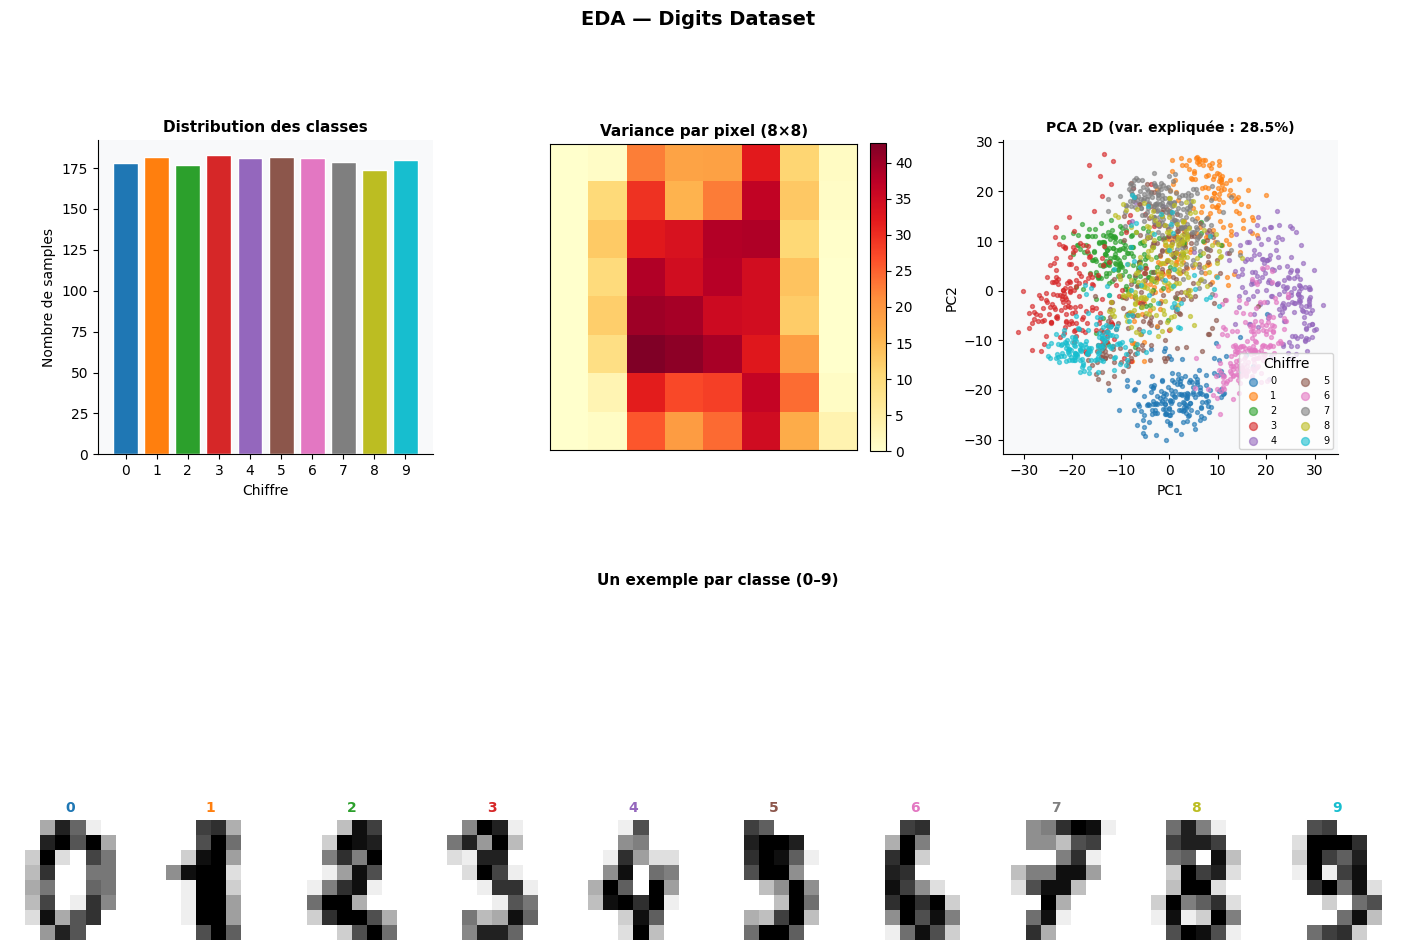

In [3]:
# ── 1. Chargement ──────────────────────────────────────────────────────────────
digits = load_digits()
X_raw  = digits.data       # (1797, 64)
y_raw  = digits.target     # labels 0–9

print("=" * 55)
print("  DIGITS — APERÇU GÉNÉRAL")
print("=" * 55)
print(f"  Samples      : {X_raw.shape[0]}")
print(f"  Features     : {X_raw.shape[1]} (pixels 8×8)")
print(f"  Classes      : {np.unique(y_raw).tolist()}")
print(f"  Valeurs NaN  : {np.isnan(X_raw).sum()}")

print("\n" + "=" * 55)
print("  DISTRIBUTION DES CLASSES")
print("=" * 55)
unique, counts = np.unique(y_raw, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Chiffre {u} : {c} samples")

print("\n" + "=" * 55)
print("  STATISTIQUES DESCRIPTIVES (pixels)")
print("=" * 55)
df = pd.DataFrame(X_raw)
print(df.describe().round(2).iloc[:, :8].to_string())

print("\n" + "=" * 55)
print("  VARIANCE MOYENNE PAR PIXEL")
print("=" * 55)
pixel_var = X_raw.var(axis=0).reshape(8, 8)
print(f"  Variance min  : {pixel_var.min():.3f}  (pixels de bord)")
print(f"  Variance max  : {pixel_var.max():.3f}  (centre du chiffre)")
print(f"  Variance moy  : {pixel_var.mean():.3f}")

# ── Visualisations EDA ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

colors_10 = plt.cm.tab10(np.linspace(0, 1, 10))

# 1. Distribution des classes
ax0 = fig.add_subplot(gs[0, 0])
ax0.bar(unique, counts, color=colors_10, edgecolor='white')
ax0.set_title('Distribution des classes', fontsize=11, fontweight='bold')
ax0.set_xlabel('Chiffre')
ax0.set_ylabel('Nombre de samples')
ax0.set_xticks(unique)
ax0.set_facecolor('#f8f9fa')
ax0.spines[['top','right']].set_visible(False)

# 2. Variance par pixel (heatmap 8x8)
ax1 = fig.add_subplot(gs[0, 1])
im = ax1.imshow(pixel_var, cmap='YlOrRd')
plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
ax1.set_title('Variance par pixel (8×8)', fontsize=11, fontweight='bold')
ax1.set_xticks([])
ax1.set_yticks([])

# 3. PCA 2D — aperçu de la séparabilité
ax2 = fig.add_subplot(gs[0, 2])
pca_eda = PCA(n_components=2, random_state=42)
X_pca2  = pca_eda.fit_transform(X_raw)
for i in range(10):
    mask = y_raw == i
    ax2.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                color=colors_10[i], label=str(i), s=8, alpha=0.6)
ax2.set_title(f'PCA 2D (var. expliquée : {pca_eda.explained_variance_ratio_.sum()*100:.1f}%)',
              fontsize=10, fontweight='bold')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.legend(title='Chiffre', fontsize=7, ncol=2,
           loc='lower right', markerscale=2)
ax2.set_facecolor('#f8f9fa')
ax2.spines[['top','right']].set_visible(False)

# 4. Exemples de chiffres (un par classe)
ax3 = fig.add_subplot(gs[1, :])
ax3.axis('off')
ax3.set_title('Un exemple par classe (0–9)', fontsize=11,
              fontweight='bold', pad=8)
for i in range(10):
    idx  = np.where(y_raw == i)[0][0]
    ax_i = fig.add_axes([0.07 + i * 0.088, 0.07, 0.075, 0.14])
    ax_i.imshow(X_raw[idx].reshape(8, 8), cmap='gray_r')
    ax_i.set_title(str(i), fontsize=10, fontweight='bold',
                   color=colors_10[i])
    ax_i.axis('off')

fig.suptitle('EDA — Digits Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.show();

In [4]:
# ── Preprocessing ──────────────────────────────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y_raw, test_size=0.30, random_state=42, stratify=y_raw
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Train : {X_train.shape[0]} samples")
print(f"Val   : {X_val.shape[0]} samples")
print(f"Test  : {X_test.shape[0]} samples")


# ── Entraînement K-Means ──────────────────────────────────────────────────────
# K-Means est non supervisé : on l'entraîne sur X_train SANS les labels.
# Les labels servent uniquement à évaluer la cohérence des clusters.
model = KMeans(n_clusters=10, init='k-means++', n_init=20, random_state=42)
model.fit(X_train)


# ── Alignement cluster → label (Hungarian algorithm) ─────────────────────────
def align_labels(y_true, y_pred, n_clusters=10):
    """
    K-Means assigne des indices arbitraires aux clusters.
    On utilise l'algorithme hongrois pour faire correspondre
    chaque cluster à la classe réelle la plus représentée.
    """
    cm  = confusion_matrix(y_true, y_pred, labels=list(range(n_clusters)))
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    return np.array([mapping.get(p, p) for p in y_pred])


def evaluate_clustering(model, X, y, split_name):
    labels_pred = model.predict(X)
    labels_aligned = align_labels(y, labels_pred)

    ari  = adjusted_rand_score(y, labels_pred)
    nmi  = normalized_mutual_info_score(y, labels_pred)
    sil  = silhouette_score(X, labels_pred, sample_size=500, random_state=42)
    acc  = (labels_aligned == y).mean()

    print(f"\n{'='*52}")
    print(f"  {split_name}")
    print(f"{'='*52}")
    print(f"  Accuracy (après alignement) : {acc:.4f}")
    print(f"  Adjusted Rand Index (ARI)   : {ari:.4f}")
    print(f"  Normalized Mutual Info (NMI): {nmi:.4f}")
    print(f"  Silhouette Score            : {sil:.4f}")
    return labels_pred, labels_aligned


labels_val,  aligned_val  = evaluate_clustering(model, X_val,  y_val,  "VALIDATION SET")
labels_test, aligned_test = evaluate_clustering(model, X_test, y_test, "TEST SET")

Train : 1257 samples
Val   : 270 samples
Test  : 270 samples


  File "C:\Users\afagn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


  VALIDATION SET
  Accuracy (après alignement) : 0.5815
  Adjusted Rand Index (ARI)   : 0.4409
  Normalized Mutual Info (NMI): 0.6259
  Silhouette Score            : 0.1142

  TEST SET
  Accuracy (après alignement) : 0.6222
  Adjusted Rand Index (ARI)   : 0.4997
  Normalized Mutual Info (NMI): 0.6929
  Silhouette Score            : 0.1488


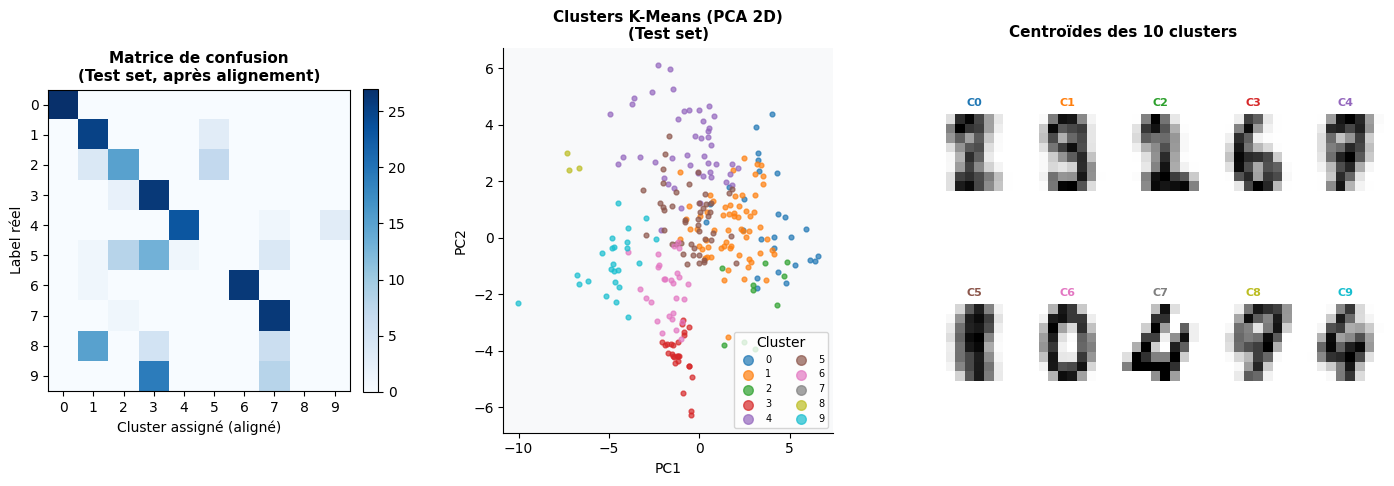

In [6]:
# ── Panel de visualisation — light mode ───────────────────────────────────────
fig = plt.figure(figsize=(16, 5))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# ── 1. Matrice de confusion alignée (test) ────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cm_test = confusion_matrix(y_test, aligned_test)
im = ax1.imshow(cm_test, cmap='Blues')
plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
ax1.set_xticks(range(10))
ax1.set_yticks(range(10))
ax1.set_xlabel('Cluster assigné (aligné)')
ax1.set_ylabel('Label réel')
ax1.set_title('Matrice de confusion\n(Test set, après alignement)',
              fontsize=11, fontweight='bold')

# ── 2. PCA 2D — clusters vs labels réels (test) ───────────────────────────────
pca_viz = PCA(n_components=2, random_state=42)
X_all   = np.vstack([X_train, X_val, X_test])
pca_viz.fit(X_all)
X_test_2d = pca_viz.transform(X_test)

ax2 = fig.add_subplot(gs[0, 1])
for i in range(10):
    mask = labels_test == i
    ax2.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
                color=colors_10[i], s=12, alpha=0.7, label=str(i))
ax2.set_title('Clusters K-Means (PCA 2D)\n(Test set)', fontsize=11, fontweight='bold')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.legend(title='Cluster', fontsize=7, ncol=2,
           loc='lower right', markerscale=2)
ax2.set_facecolor('#f8f9fa')
ax2.spines[['top','right']].set_visible(False)

# ── 3. Centroïdes des clusters (images 8×8) ───────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')
ax3.set_title('Centroïdes des 10 clusters', fontsize=11,
              fontweight='bold', pad=8)

# On inverse le scaler pour afficher les centroïdes dans l'espace original
centroids_orig = scaler.inverse_transform(model.cluster_centers_)

for i in range(10):
    ax_c = fig.add_axes([0.68 + (i % 5) * 0.058,
                         0.52 - (i // 5) * 0.38,
                         0.048, 0.30])
    ax_c.imshow(centroids_orig[i].reshape(8, 8), cmap='gray_r')
    ax_c.set_title(f'C{i}', fontsize=8, color=colors_10[i], fontweight='bold')
    ax_c.axis('off')

plt.show();